In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import colorsys

sns.set_style("whitegrid")
base_path = Path("/home/jing/Desktop/realistic-al/experiments/activelearning")

def get_aubc(performance: np.ndarray) -> float:
    if len(performance) <= 1:
        return 0.0
    dx = 1 / (len(performance) - 1)
    return np.trapz(performance, dx=dx).item()

def plot_runs(runs_to_plot, color_palette, plot_name, show_std=True):
    all_data = []
    aubc_results = []

    for method_name, run_paths in runs_to_plot.items():
        for rel_path in run_paths:
            seed_dir = base_path / rel_path
            metric_file = seed_dir / "test_metrics.csv"
            
            if not metric_file.exists():
                print(f"Skipping missing file: {metric_file}")
                continue
                
            try:
                df = pd.read_csv(metric_file)
                df = df.reset_index(drop=True)
                if "test/acc" in df.columns:
                    df.rename(columns={"test/acc": "Accuracy"}, inplace=True)
                if "test/bacc" in df.columns:
                    df.rename(columns={"test/bacc": "Balanced Accuracy"}, inplace=True)
                    
                df["Method"] = method_name
                df["Cycle"] = df.index
                df["Run"] = seed_dir.name
                all_data.append(df)
                
                if "Accuracy" in df.columns:
                    acc_values = df["Accuracy"].values
                    aubc = get_aubc(acc_values)
                    aubc_results.append({
                        "Method": method_name,
                        "Run": seed_dir.name,
                        "AUBC": aubc,
                    })
            except Exception as e:
                print(f"Error processing {metric_file}: {e}")

    if not all_data:
        print(f"No valid data found for plot: {plot_name}")
        return

    plot_df = pd.concat(all_data, ignore_index=True)
    unique_methods = plot_df["Method"].unique()
    
    current_palette = {}
    other_colors = sns.color_palette("husl", len(unique_methods))
    c_idx = 0
    for m in unique_methods:
        if m in color_palette:
            current_palette[m] = color_palette[m]
        elif any(m.lower().startswith(base.lower()) for base in color_palette):
            current_palette[m] = other_colors[c_idx]
            c_idx += 1
        else:
            current_palette[m] = other_colors[c_idx]
            c_idx += 1

    # --- Plotting Accuracy ---
    if "Accuracy" in plot_df.columns:
        plt.figure(figsize=(10, 6))
        sns.lineplot(
            data=plot_df,
            x="Cycle",
            y="Accuracy",
            hue="Method",
            palette=current_palette,
            ci="sd" if show_std else None,
            marker="o"
        )
        plt.title(f"{plot_name} - Accuracy")
        plt.ylabel("Test Accuracy")
        plt.xlabel("Active Learning Cycle")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    # --- Plotting Balanced Accuracy ---
    if "Balanced Accuracy" in plot_df.columns:
        plt.figure(figsize=(10, 6))
        sns.lineplot(
            data=plot_df,
            x="Cycle",
            y="Balanced Accuracy",
            hue="Method",
            palette=current_palette,
            ci="sd" if show_std else None,
            marker="o"
        )
        plt.title(f"{plot_name} - Balanced Accuracy")
        plt.ylabel("Test Balanced Accuracy")
        plt.xlabel("Active Learning Cycle")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    if aubc_results:
        aubc_df = pd.DataFrame(aubc_results)
        aubc_summary = aubc_df.groupby("Method")["AUBC"].agg(["mean", "std"]).reset_index()
        aubc_summary = aubc_summary.sort_values('mean', ascending=False)
        print(f"\n--- AUBC Summary ({plot_name}) ---")
        print(aubc_summary)

    return plot_df, aubc_results


In [2]:
PALETTE = {
    "BALD": "#d62728",
    "Core-Set": "#1f77b4",
    "Entropy": "#2ca02c",
    "BADGE": "#9467bd",
    "Random": "#6B6B6B",
    "Vendi": "#3939C6",
    "Bandit": "#e79e00",
}

In [3]:
basic_cifar10imb = {
    "BALD": sorted((base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0.5_aug-cifar_randaugmentMC_acq-bald_ep-200__wloss-True")).iterdir())[-3:],
    "Core-Set": sorted((base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-kcentergreedy_ep-200__wloss-True")).iterdir())[-3:],
    "Entropy": sorted((base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-entropy_ep-200__wloss-True")).iterdir())[-3:],
    "BADGE": sorted((base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-badge_ep-200__wloss-True")).iterdir())[-3:],
    "Random": sorted((base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-random_ep-200__wloss-True")).iterdir())[-3:],
    "Vendi": sorted((base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-vendi_ep-200__wloss-True")).iterdir())[-3:],
    "Bandit": sorted((base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-vendi_ep-200__wloss-True")).iterdir())[-3:],
}


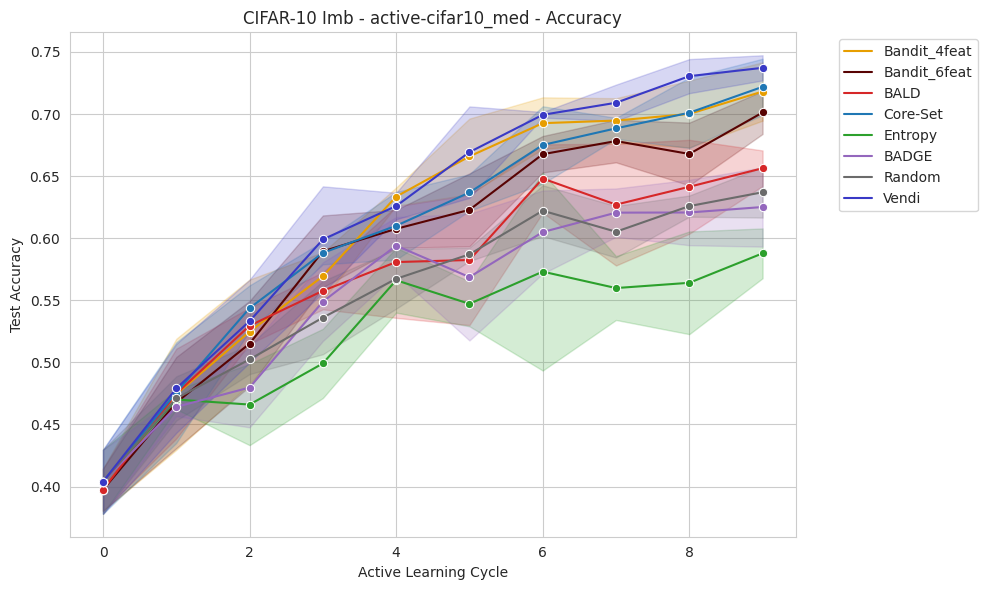


--- AUBC Summary (CIFAR-10 Imb - active-cifar10_med) ---
         Method      mean       std
7         Vendi  0.624022  0.014617
2  Bandit_4feat  0.612576  0.004591
4      Core-Set  0.609120  0.012961
3  Bandit_6feat  0.596204  0.015419
1          BALD  0.574317  0.027998
6        Random  0.559726  0.013994
0         BADGE  0.557383  0.021401
5       Entropy  0.526841  0.026595


In [6]:
additional_cifar10imb = {
    "Bandit_4feat": [
        base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0.5_aug-cifar_randaugmentMC_acq-bandit_ep-200__wloss-True/2026-01-10_00-32-05-722387"),
        base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0.5_aug-cifar_randaugmentMC_acq-bandit_ep-200__wloss-True/2026-01-10_03-15-31-189077"),
        base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0.5_aug-cifar_randaugmentMC_acq-bandit_ep-200__wloss-True/2026-01-10_05-55-41-916575"),
    ],
    "Bandit_6feat": [
        base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0.5_aug-cifar_randaugmentMC_acq-bandit_norm-minmax_kernel-rbf_gamma-1.0_ep-200__wloss-True//2026-03-06_19-33-11-026974"),
        base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0.5_aug-cifar_randaugmentMC_acq-bandit_norm-minmax_kernel-rbf_gamma-1.0_ep-200__wloss-True/2026-03-06_22-03-04-913857"),
        base_path / Path("cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0.5_aug-cifar_randaugmentMC_acq-bandit_norm-minmax_kernel-rbf_gamma-1.0_ep-200__wloss-True/2026-03-07_00-48-56-741682")
    ],
}
additional_cifar10imb.update(basic_cifar10imb)
additional_cifar10imb.pop("Bandit")

palette_cifar10imb = {
    "Bandit_4feat": "#e79e00",
    "Bandit_6feat": "#580303", # You can map specific features directly to exact hex codes
}
palette_cifar10imb.update(PALETTE)
palette_cifar10imb.pop("Bandit")

# print(additional_cifar10imb.keys(), palette_cifar10imb.keys())
df, aubc = plot_runs(additional_cifar10imb, palette_cifar10imb , "CIFAR-10 Imb - active-cifar10_med")

In [9]:
palette_cifar10imb